# 03 — EDA: Spatial Join, Supply Baseline, and Equity Narrative

Builds on 02_data_cleaning.ipynb.

**Change in this version: `gla_evse_join.csv` is no longer used.** That crosswalk table was
never listed in the proposal's Section 4 data sources, and a data-quality issue in its
location_id↔evse_id mapping was producing physically implausible eⱼ values (500+ registered
on-street EVSEs in a single LSOA — not plausible given ~21,000 on-street locations across
~4,994 LSOAs London-wide).

This version works only with the two datasets the proposal actually specifies:
`join_august2025.csv` and `OpenStreetEV_GLA.csv`. Consequence: eⱼ is now a **location-level**
count (number of registered on-street *locations* per LSOA), not a device/connector-level count.
For a location with zero sessions this week, we know it exists but not how many individual
connectors it has — that finer granularity required the dropped crosswalk. This is declared as
a new limitation (see note in Section 2) and is consistent with the "Location > Device > EV
charger > Connector" hierarchy in Zapmap's own data definitions — eⱼ now measures Locations.


## 0. Setup and reload cleaned data

In [35]:
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import os
from scipy.stats import pearsonr

BASE = "/Users/alexia/Documents/CASA/Dissertation"

census_london = pd.read_csv(os.path.join(BASE, "05_processed/census_london_clean.csv"))
imd_london    = pd.read_csv(os.path.join(BASE, "05_processed/imd_london_clean.csv"))
osev_london   = pd.read_csv(os.path.join(BASE, "05_processed/osev_london_clean.csv"))
zapmap_clean  = pd.read_csv(os.path.join(BASE, "05_processed/zapmap_clean.csv"), parse_dates=["charging_start"])
evse_ur       = pd.read_csv(os.path.join(BASE, "05_processed/evse_ur_clean.csv"))

figures_dir = os.path.join(BASE, "06_outputs/figures")
os.makedirs(figures_dir, exist_ok=True)

# Ensure consistent ID type before spatial join
osev_london["location_id"] = osev_london["location_id"].astype(str)

print("Datasets reloaded. (gla_evse_join.csv is no longer used -- see Section 0 note.)")
print(f"census_london: {census_london.shape}, imd_london: {imd_london.shape}")
print(f"osev_london: {osev_london.shape}, zapmap_clean: {zapmap_clean.shape}")
print(f"evse_ur: {evse_ur.shape}")


Datasets reloaded. (gla_evse_join.csv is no longer used -- see Section 0 note.)
census_london: (4994, 8), imd_london: (4994, 10)
osev_london: (23015, 11), zapmap_clean: (63105, 20)
evse_ur: (10465, 6)


In [36]:
lsoa_boundaries = gpd.read_file(os.path.join(BASE, "03_data/demand/spatial/LSOA_2021_EW_BGC_V5.shp"))
if lsoa_boundaries.crs is None or lsoa_boundaries.crs.to_epsg() != 27700:
    lsoa_boundaries = lsoa_boundaries.to_crs(epsg=27700)

london_codes = set(census_london["lsoa_code"])
lsoa_london = lsoa_boundaries[lsoa_boundaries["LSOA21CD"].isin(london_codes)].copy()
lsoa_london = lsoa_london.rename(columns={"LSOA21CD": "lsoa_code"})[["lsoa_code", "geometry"]]

print(f"LSOA boundaries matched: {len(lsoa_london)} / {len(london_codes)} expected")

LSOA boundaries matched: 4994 / 4994 expected


## 1. Build the on-street location registry and spatial-join to LSOA

`onstreet_locations` = every distinct location in `OpenStreetEV_GLA` with
`location_category == "On-Street"`. Session-level utilisation (`ur_j`, computed per EVSE in
02_data_cleaning from `join_august2025.csv`) is collapsed to location level and merged in;
a location with zero sessions this week gets `ur_j = 0` at the location level (same convention
as the proposal's device-level rule, applied one level up).

No crosswalk table is used: `join_august2025.csv` already carries its own `location_id` column
(visible back in 01_data_loading's peek), and coordinates are taken only from `OpenStreetEV_GLA`
throughout, which also avoids any coordinate mismatch between the two sources.


In [37]:
# On-street location registry, directly from OpenStreetEV_GLA -- no gla_evse_join.csv crosswalk
onstreet_locations = (
    osev_london.loc[osev_london["location_category"].eq("On-Street"),
                     ["location_id", "latitude", "longitude"]]
    .drop_duplicates(subset=["location_id"])
    .reset_index(drop=True)
)

print(f"On-street locations (registered, OpenStreetEV_GLA): {len(onstreet_locations)}")
print(f"Missing coordinates: {onstreet_locations[['latitude', 'longitude']].isna().sum().sum()}")


On-street locations (registered, OpenStreetEV_GLA): 21366
Missing coordinates: 0


In [38]:
# Collapse device-level ur_j (evse_ur, from 02_data_cleaning) to location level.
# A location's utilisation contribution:
#   - seff_loc = sum of ur_j across its devices with >=1 session this week (feeds Sᵢᵉᶠᶠ)
#   - ubar_loc = mean of ur_j across those same devices (feeds ūᵢ)
# Locations with zero sessions this week never appear in evse_ur; filled to 0 below,
# consistent with the proposal's ur_j = 0 convention for unobserved EVSEs (Section 5.2).
session_loc_agg = evse_ur.groupby("location_id").agg(
    seff_loc=("ur_j", "sum"),
    ubar_loc=("ur_j", "mean"),
    n_devices_with_session=("evse_id", "count"),
).reset_index()

onstreet_locations = onstreet_locations.merge(session_loc_agg, on="location_id", how="left")
onstreet_locations["seff_loc"] = onstreet_locations["seff_loc"].fillna(0.0)
onstreet_locations["ubar_loc"] = onstreet_locations["ubar_loc"].fillna(0.0)
onstreet_locations["has_session"] = onstreet_locations["n_devices_with_session"].fillna(0) > 0

print("=== On-street location registry (location-level) ===")
print("Total on-street locations:   ", len(onstreet_locations))
print("With >=1 session this week:  ", onstreet_locations["has_session"].sum())
print("Zero-session (ur_j set to 0):", (~onstreet_locations["has_session"]).sum())
print()
print(onstreet_locations[["seff_loc", "ubar_loc"]].describe())


=== On-street location registry (location-level) ===
Total on-street locations:    21366
With >=1 session this week:   7032
Zero-session (ur_j set to 0): 14334

           seff_loc      ubar_loc
count  21366.000000  21366.000000
mean       0.093536      0.076004
std        0.245101      0.201117
min        0.000000      0.000000
25%        0.000000      0.000000
50%        0.000000      0.000000
75%        0.000198      0.000198
max        6.101984      0.999504


In [39]:
loc_gdf = gpd.GeoDataFrame(
    onstreet_locations,
    geometry=gpd.points_from_xy(onstreet_locations["longitude"], onstreet_locations["latitude"]),
    crs="EPSG:4326",
).to_crs(epsg=27700)

loc_joined = gpd.sjoin(loc_gdf, lsoa_london, how="left", predicate="within").drop(columns=["index_right"])
matched = loc_joined["lsoa_code"].notna().sum()
print(f"On-street locations matched to a London LSOA: {matched} / {len(loc_joined)}")


On-street locations matched to a London LSOA: 21366 / 21366


## 2. Aggregate eⱼ, Sᵢᵉᶠᶠ, ūᵢ, has_evse_i to LSOA level (on-street locations)

**eⱼ counts registered on-street *locations*, not individual connectors** (see Section 0 note).
A location may host more than one connector; that finer count is not available without the
dropped `gla_evse_join.csv` crosswalk. Declared as Limitation L11, alongside the existing
top-coding approximation for Cᵢ (L9) — both are documented simplifications of a discrete count.


In [40]:
loc_matched = loc_joined.dropna(subset=["lsoa_code"])

lsoa_evse_agg = loc_matched.groupby("lsoa_code").agg(
    ej=("location_id", "count"),
    seff=("seff_loc", "sum"),
    ubar_i=("ubar_loc", "mean"),
).reset_index()

seff_london = census_london[["lsoa_code", "lsoa_name"]].merge(lsoa_evse_agg, on="lsoa_code", how="left")
seff_london["ej"] = seff_london["ej"].fillna(0).astype(int)
seff_london["seff"] = seff_london["seff"].fillna(0.0)
seff_london["has_evse_i"] = seff_london["ej"] > 0

print("=== eⱼ / Sᵢᵉᶠᶠ / ūᵢ / has_evse_i summary (on-street locations) ===")
print(f"LSOAs with has_evse_i = True:  {seff_london['has_evse_i'].sum()}")
print(f"LSOAs with has_evse_i = False: {(~seff_london['has_evse_i']).sum()}")
print()
print("eⱼ stats:"); print(seff_london["ej"].describe())
print()
print("Sᵢᵉᶠᶠ stats:"); print(seff_london["seff"].describe())
print()
print("ūᵢ stats (has_evse_i = True only):")
print(seff_london.loc[seff_london["has_evse_i"], "ubar_i"].describe())

print(f"\nSanity check -- max eⱼ per LSOA: {seff_london['ej'].max()} "
      f"(should be a small number, e.g. well under 30; a large value here would indicate "
      f"a residual data issue, not a crosswalk-table issue this time)")

output_path = os.path.join(BASE, "05_processed/seff_london.csv")
seff_london.to_csv(output_path, index=False)
print(f"\nSaved to: {output_path}")


=== eⱼ / Sᵢᵉᶠᶠ / ūᵢ / has_evse_i summary (on-street locations) ===
LSOAs with has_evse_i = True:  3157
LSOAs with has_evse_i = False: 1837

eⱼ stats:
count    4994.000000
mean        4.278334
std         7.049439
min         0.000000
25%         0.000000
50%         1.000000
75%         5.000000
max        63.000000
Name: ej, dtype: float64

Sᵢᵉᶠᶠ stats:
count    4994.000000
mean        0.400179
std         0.974035
min         0.000000
25%         0.000000
50%         0.000000
75%         0.378125
max        11.385020
Name: seff, dtype: float64

ūᵢ stats (has_evse_i = True only):
count    3157.000000
mean        0.103386
std         0.177193
min         0.000000
25%         0.000000
50%         0.004762
75%         0.135979
max         0.962401
Name: ubar_i, dtype: float64

Sanity check -- max eⱼ per LSOA: 63 (should be a small number, e.g. well under 30; a large value here would indicate a residual data issue, not a crosswalk-table issue this time)

Saved to: /Users/alexia/Documents/

## 3. Charging desert identification — Condition A vs Condition B

In [41]:
condition_a = ~seff_london["has_evse_i"]
condition_b = seff_london["has_evse_i"] & (seff_london["seff"] < 0.01)

seff_london["desert_condition"] = np.select(
    [condition_a, condition_b], ["A_true_desert", "B_underutilised"], default="normal"
)
print(seff_london["desert_condition"].value_counts())
seff_london.to_csv(os.path.join(BASE, "05_processed/seff_london.csv"), index=False)

desert_condition
A_true_desert      1837
normal             1677
B_underutilised    1480
Name: count, dtype: int64


## 4. EDA narrative: Fig A -> Fig B -> Fig C

### Fig A — number of registered on-street locations (eⱼ) per LSOA


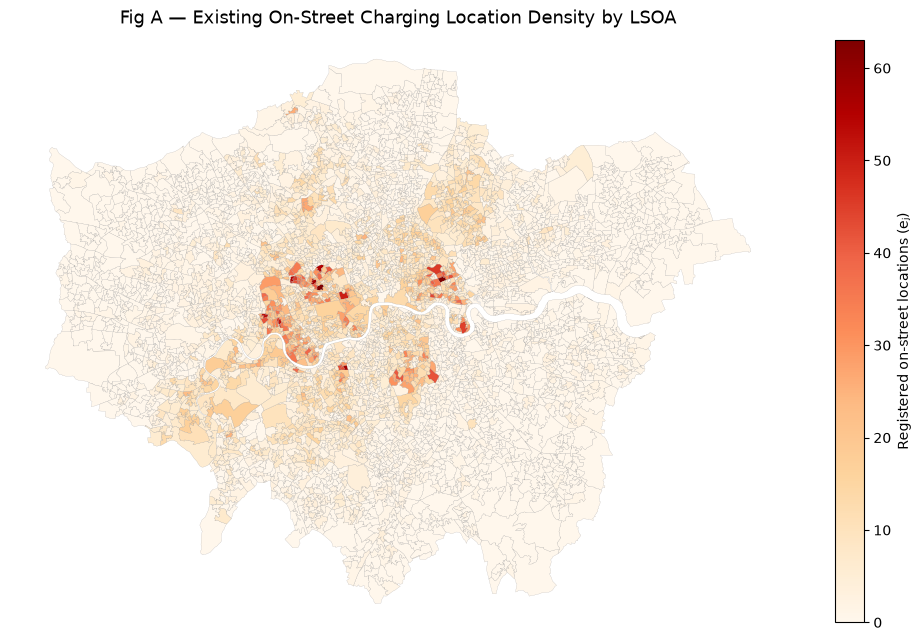

In [42]:
fig_a_map = lsoa_london.merge(seff_london[["lsoa_code", "ej"]], on="lsoa_code", how="left")
fig, ax = plt.subplots(figsize=(10, 10))
fig_a_map.plot(column="ej", cmap="OrRd", linewidth=0.1, edgecolor="grey",
               legend=True, ax=ax, legend_kwds={"label": "Registered on-street locations (eⱼ)", "shrink": 0.6})
ax.set_title("Fig A — Existing On-Street Charging Location Density by LSOA", fontsize=13)
ax.axis("off")
plt.tight_layout()
plt.savefig(os.path.join(figures_dir, "fig_a_evse_count.png"), dpi=300, bbox_inches="tight")
plt.show()


### Fig B — mean realised utilisation (ūᵢ), "been-used" map

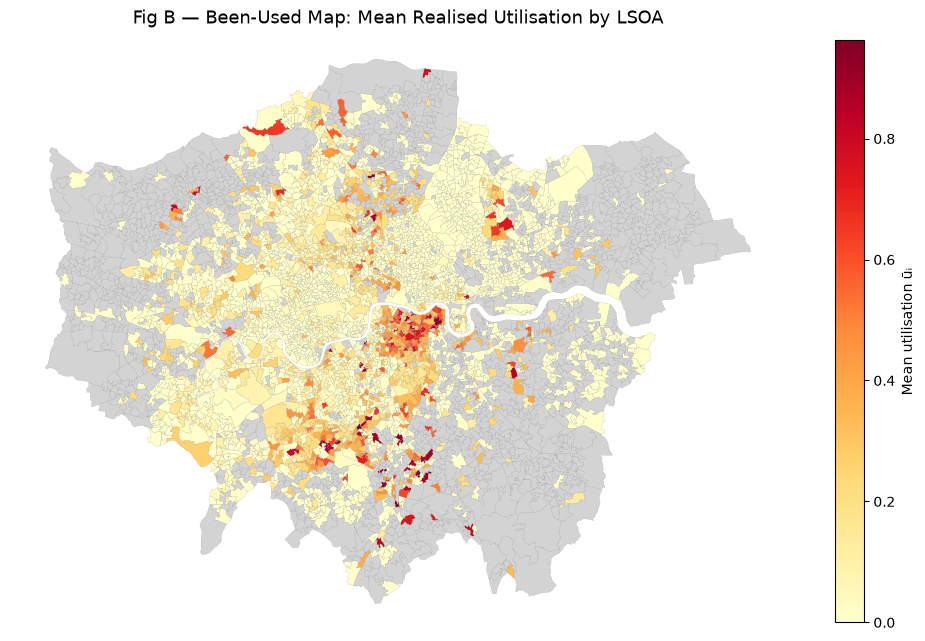

In [43]:
fig_b_map = lsoa_london.merge(seff_london[["lsoa_code", "ubar_i", "has_evse_i"]], on="lsoa_code", how="left")
fig, ax = plt.subplots(figsize=(10, 10))
fig_b_map.plot(column="ubar_i", cmap="YlOrRd", linewidth=0.1, edgecolor="grey",
               legend=True, ax=ax, missing_kwds={"color": "lightgrey", "label": "No registered EVSE"},
               legend_kwds={"label": "Mean utilisation ūᵢ", "shrink": 0.6})
ax.set_title("Fig B — Been-Used Map: Mean Realised Utilisation by LSOA", fontsize=13)
ax.axis("off")
plt.tight_layout()
plt.savefig(os.path.join(figures_dir, "fig_b_utilisation.png"), dpi=300, bbox_inches="tight")
plt.show()

### Fig C — income deprivation (income_score) per LSOA

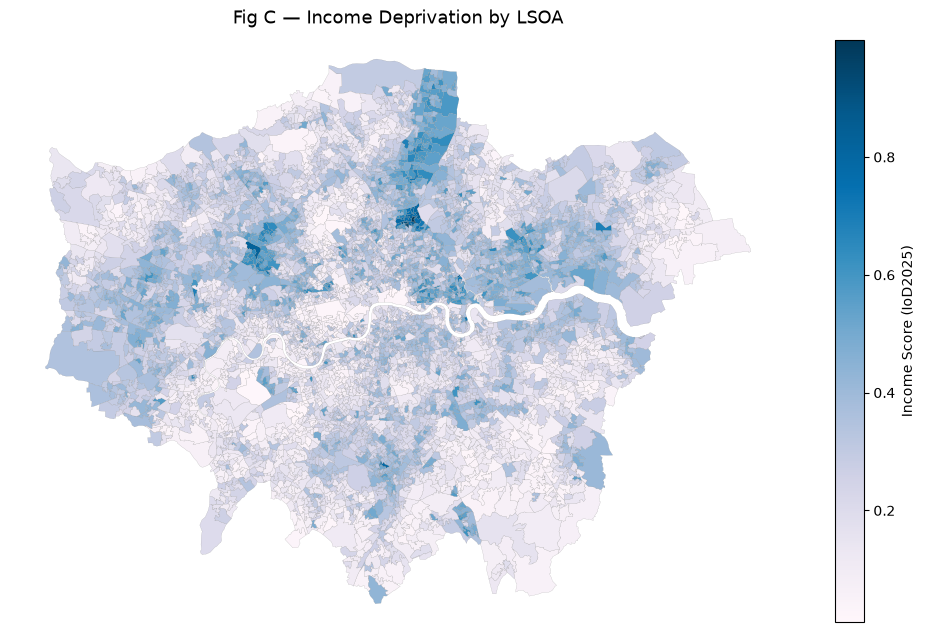

In [44]:
fig_c_map = lsoa_london.merge(imd_london[["lsoa_code", "income_score"]], on="lsoa_code", how="left")
fig, ax = plt.subplots(figsize=(10, 10))
fig_c_map.plot(column="income_score", cmap="PuBu", linewidth=0.1, edgecolor="grey",
               legend=True, ax=ax, legend_kwds={"label": "Income Score (IoD2025)", "shrink": 0.6})
ax.set_title("Fig C — Income Deprivation by LSOA", fontsize=13)
ax.axis("off")
plt.tight_layout()
plt.savefig(os.path.join(figures_dir, "fig_c_income_deprivation.png"), dpi=300, bbox_inches="tight")
plt.show()

## 5. Correlation: income score vs Sᵢᵉᶠᶠ

In [45]:
corr_table = (
    census_london[["lsoa_code", "lsoa_name", "Hi"]]
    .merge(imd_london[["lsoa_code", "income_score", "income_decile"]], on="lsoa_code")
    .merge(seff_london[["lsoa_code", "ej", "seff", "ubar_i", "has_evse_i"]], on="lsoa_code")
)
corr_table["ej_per_1000_hh"]   = corr_table["ej"]   / corr_table["Hi"] * 1000
corr_table["seff_per_1000_hh"] = corr_table["seff"] / corr_table["Hi"] * 1000

pairs = [
    ("income_score", "ej_per_1000_hh",   "Income score vs on-street location count per 1,000 households"),
    ("income_score", "seff_per_1000_hh", "Income score vs Sᵢᵉᶠᶠ per 1,000 households"),
]
print("=== Pearson correlations ===")
for col_x, col_y, label in pairs:
    sub = corr_table.dropna(subset=[col_x, col_y])
    r, p = pearsonr(sub[col_x], sub[col_y])
    print(f"{label}: r = {r:.4f}, p = {p:.4g}, n = {len(sub)}")

output_path = os.path.join(BASE, "05_processed/correlation_results.csv")
pd.DataFrame(
    [(l, *pearsonr(corr_table.dropna(subset=[x,y])[x], corr_table.dropna(subset=[x,y])[y]), len(corr_table.dropna(subset=[x,y])))
     for x,y,l in pairs], columns=["pair","pearson_r","p_value","n"]
).to_csv(output_path, index=False)
print(f"\nSaved to: {output_path}")


=== Pearson correlations ===
Income score vs on-street location count per 1,000 households: r = -0.0877, p = 5.408e-10, n = 4994
Income score vs Sᵢᵉᶠᶠ per 1,000 households: r = -0.0639, p = 6.269e-06, n = 4994

Saved to: /Users/alexia/Documents/CASA/Dissertation/05_processed/correlation_results.csv


### Optional robustness check (subject to time and diagnostics)

Prior run on the (now-dropped) `gla_evse_join`-based device-level eⱼ found Moran's I = 0.386
(p = 0.001) on the OLS residuals — significant spatial autocorrelation, so a full SAR regression
was warranted per the proposal's declared rule. That figure was computed under the previous,
now-removed device-level definition and is kept here only as a historical note; re-run below on
the location-level numbers to get the current value.


In [46]:
try:
    import libpysal
    from esda.moran import Moran
    import statsmodels.api as sm

    reg_data = corr_table.dropna(subset=["income_score", "seff_per_1000_hh"]).copy()
    X = sm.add_constant(reg_data["income_score"])
    ols = sm.OLS(reg_data["seff_per_1000_hh"], X).fit()
    reg_data["resid"] = ols.resid

    reg_geo = lsoa_london.merge(reg_data[["lsoa_code", "resid"]], on="lsoa_code")
    w = libpysal.weights.Queen.from_dataframe(reg_geo)
    w.transform = "r"
    moran = Moran(reg_geo["resid"].values, w)
    print(f"Moran's I on OLS residuals: {moran.I:.4f}, p = {moran.p_sim:.4f}")
    if moran.p_sim < 0.05:
        print("Significant residual spatial autocorrelation -- a full spatial-lag/SAR")
        print("regression is warranted as a robustness check (proposal Section 7).")
    else:
        print("No significant residual spatial autocorrelation -- plain Pearson r stands.")
except ImportError:
    print("esda/libpysal/statsmodels not installed -- optional, skip for now.")

/var/folders/ns/mq6gshc5381576s51jjzgybm0000gn/T/ipykernel_43655/2241814336.py:12: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  w = libpysal.weights.Queen.from_dataframe(reg_geo)


Moran's I on OLS residuals: 0.4698, p = 0.0010
Significant residual spatial autocorrelation -- a full spatial-lag/SAR
regression is warranted as a robustness check (proposal Section 7).


## 6. join_august2025.csv exploration

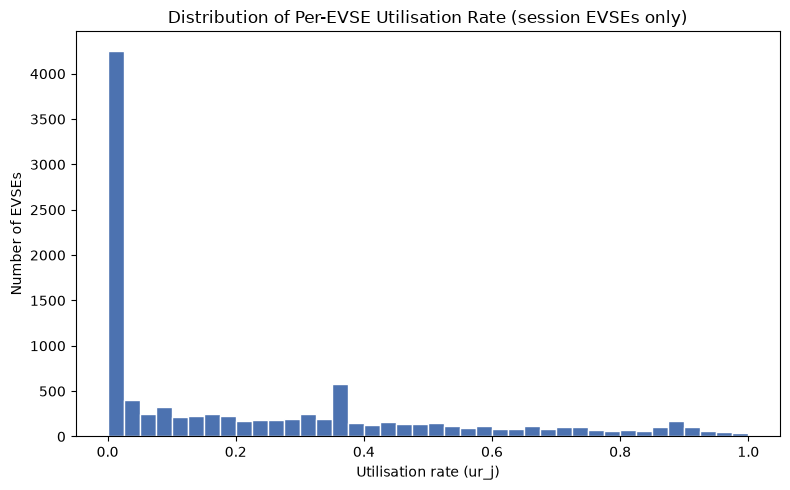

In [47]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(evse_ur["ur_j"], bins=40, color="#4C72B0", edgecolor="white")
ax.set_xlabel("Utilisation rate (ur_j)"); ax.set_ylabel("Number of EVSEs")
ax.set_title("Distribution of Per-EVSE Utilisation Rate (session EVSEs only)")
plt.tight_layout()
plt.savefig(os.path.join(figures_dir, "fig_ur_j_distribution.png"), dpi=300, bbox_inches="tight")
plt.show()

power_band
1. Slow           8045
2. Fast (AC)      1477
2. Fast (DC)         2
3. Rapid           385
4. Ultra-rapid     556
Name: count, dtype: int64


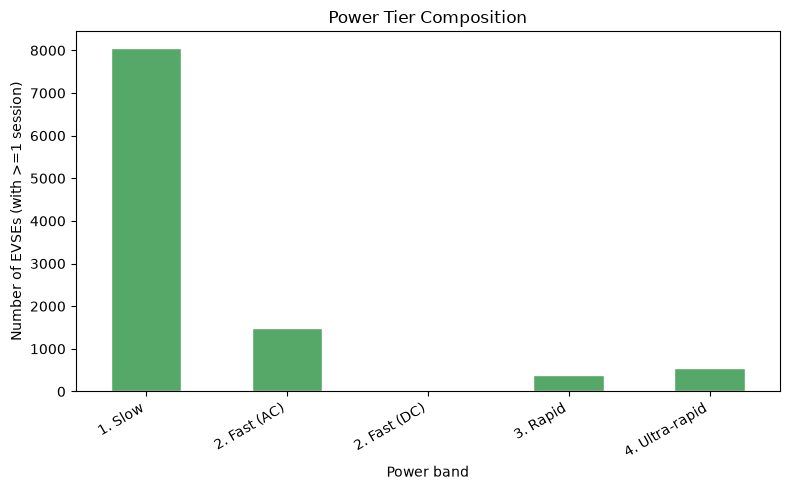

In [48]:
evse_power = zapmap_clean.groupby("evse_id")["power_band"].first().reset_index()
power_counts = evse_power["power_band"].value_counts().sort_index()
print(power_counts)

fig, ax = plt.subplots(figsize=(8, 5))
power_counts.plot(kind="bar", ax=ax, color="#55A868", edgecolor="white")
ax.set_xlabel("Power band"); ax.set_ylabel("Number of EVSEs (with >=1 session)")
ax.set_title("Power Tier Composition")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(os.path.join(figures_dir, "fig_power_tier.png"), dpi=300, bbox_inches="tight")
plt.show()

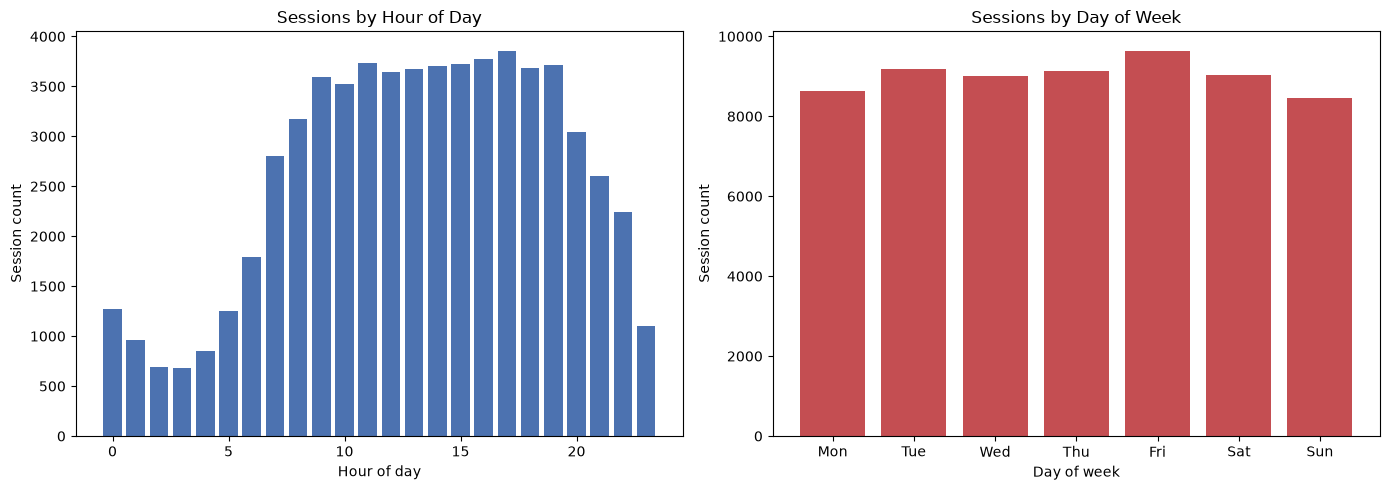

In [49]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sessions_by_hour = zapmap_clean.groupby("hour").size()
axes[0].bar(sessions_by_hour.index, sessions_by_hour.values, color="#4C72B0")
axes[0].set_xlabel("Hour of day"); axes[0].set_ylabel("Session count")
axes[0].set_title("Sessions by Hour of Day")

dow_labels = ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"]
sessions_by_dow = zapmap_clean.groupby("dayofweek").size()
axes[1].bar([dow_labels[i] for i in sessions_by_dow.index], sessions_by_dow.values, color="#C44E52")
axes[1].set_xlabel("Day of week"); axes[1].set_ylabel("Session count")
axes[1].set_title("Sessions by Day of Week")
plt.tight_layout()
plt.savefig(os.path.join(figures_dir, "fig_temporal_patterns.png"), dpi=300, bbox_inches="tight")
plt.show()

## 7. Update pipeline_summary.csv

In [50]:
pipeline_summary = pd.read_csv(os.path.join(BASE, "05_processed/pipeline_summary.csv"))
updates = {
    "On-street locations matched to LSOA via spatial join": str(matched),
    "eⱼ / Sᵢᵉᶠᶠ / Uᵢ / has_evse_i (LSOA-level)": f"Done (location-level, no gla_evse_join.csv) — {seff_london['has_evse_i'].sum()} LSOAs with has_evse_i=True",
}
for item, value in updates.items():
    if (pipeline_summary["Item"] == item).any():
        pipeline_summary.loc[pipeline_summary["Item"] == item, "Count"] = value
    else:
        pipeline_summary = pd.concat([pipeline_summary, pd.DataFrame([{"Item": item, "Count": value}])], ignore_index=True)

pipeline_summary.to_csv(os.path.join(BASE, "05_processed/pipeline_summary.csv"), index=False)
print(pipeline_summary.to_string(index=False))


                                                   Item                                                                         Count
                          LSOAs loaded (Greater London)                                                                          4994
      Household total (Hi sum, validated vs gor:London)                                                                       3423845
Total EVSE locations (OpenStreetEV_GLA, all categories)                                                                         23015
            On-street EVSE locations (OpenStreetEV_GLA)                                                                         21366
          Session records (join_august2025, post-clean)                                                                         63105
          Unique EVSEs with >=1 session (ur_j computed)                                                                         10465
              eⱼ / Sᵢᵉᶠᶠ / Uᵢ / has_evse_i (LSOA-level) Done (